# Phân loại Email Spam
## 2. Kiểm tra dữ liệu

Trước khi tiến hành phân tích, chúng ta cần xác minh tính toàn vẹn và chất lượng của tập dữ liệu thô.

Các bước kiểm tra được thực hiện:
- Số lượng mẫu và kiểu dữ liệu cơ bản
- Giá trị bị thiếu (null) trên từng cột
- Các dòng bị trùng lặp
- Phân phối các lớp (độ cân bằng nhãn)
- Kiểm tra tính hợp lệ trên từng cột cụ thể


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

df = pd.read_csv(r'../data/raw/enron_spam_data.csv')
print('Kích thước dữ liệu:', df.shape)
df.info()

Kích thước dữ liệu: (33716, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Message ID  33716 non-null  int64 
 1   Subject     33427 non-null  object
 2   Message     33345 non-null  object
 3   Spam/Ham    33716 non-null  object
 4   Date        33716 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.3+ MB


### 2.1 Giá trị bị thiếu

            Số lượng khuyết  Tỷ lệ %
Message ID                0     0.00
Subject                 289     0.86
Message                 371     1.10
Spam/Ham                  0     0.00
Date                      0     0.00


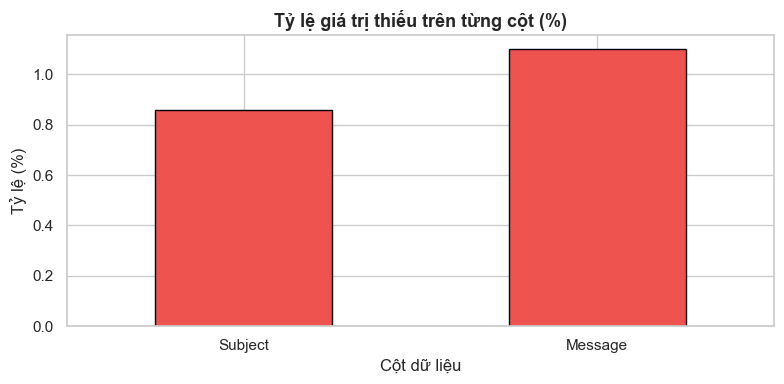

In [17]:
null_counts = df.isnull().sum()
null_pct    = (null_counts / len(df) * 100).round(2)
null_df     = pd.DataFrame({'Số lượng khuyết': null_counts, 'Tỷ lệ %': null_pct})
print(null_df)

# Trực quan hóa các cột có giá trị thiếu
missing = null_pct[null_pct > 0]
if not missing.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    missing.plot(kind='bar', ax=ax, color='#EF5350', edgecolor='black')
    ax.set_title('Tỷ lệ giá trị thiếu trên từng cột (%)', fontsize=13, fontweight='bold')
    ax.set_ylabel('Tỷ lệ (%)')
    ax.set_xlabel('Cột dữ liệu')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

### 2.2 Các dòng bị trùng lặp

In [18]:
n_dup = df.duplicated().sum()
print(f'Số dòng trùng lặp: {n_dup} ({n_dup / len(df) * 100:.2f}%)')

Số dòng trùng lặp: 0 (0.00%)


### 2.3 Phân phối lớp

Phân phối nhãn các lớp:
Spam/Ham
spam    17171
ham     16545
Name: count, dtype: int64
Tỷ lệ mất cân bằng: 1.04x


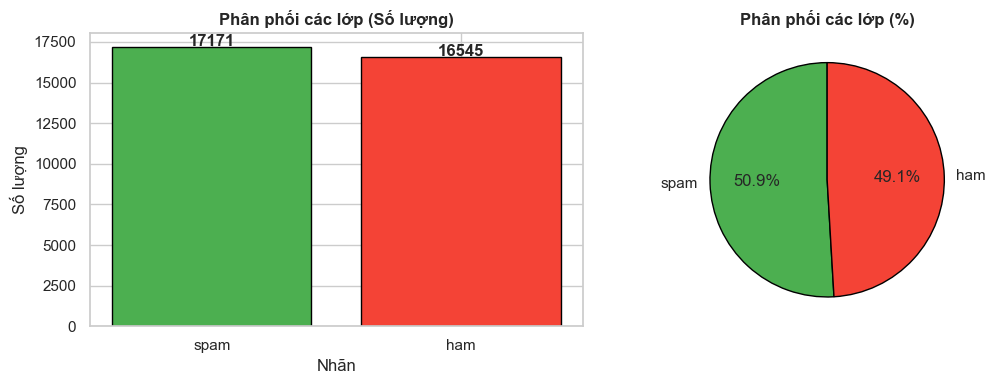

In [19]:
label_counts = df['Spam/Ham'].value_counts()
print('Phân phối nhãn các lớp:')
print(label_counts)
print(f'Tỷ lệ mất cân bằng: {label_counts.max() / label_counts.min():.2f}x')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Biểu đồ cột
colors = ['#4CAF50', '#F44336']
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Phân phối các lớp (Số lượng)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Nhãn')
axes[0].set_ylabel('Số lượng')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Biểu đồ tròn
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops=dict(edgecolor='black'))
axes[1].set_title('Phân phối các lớp (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 2.4 Kiểm tra tính hợp lệ cấp cột

In [20]:
print('Cột Subject:')
print('  Mẫu giá trị:', df['Subject'].dropna().unique()[:5])
print('  Số chuỗi rỗng:', (df['Subject'] == '').sum())

print('\nCột Message:')
msg_len = df['Message'].dropna().apply(len)
print(f'  Độ dài trung bình: {msg_len.mean():.0f} ký tự')
print(f'  Ngắn nhất / Dài nhất: {msg_len.min()} / {msg_len.max()} ký tự')

print('\nCột Date:')
print(df['Date'].describe())

Cột Subject:
  Mẫu giá trị: ['christmas tree farm pictures' 'vastar resources , inc .'
 'calpine daily gas nomination' 're : issue' 'meter 7268 nov allocation']
  Số chuỗi rỗng: 0

Cột Message:
  Độ dài trung bình: 1487 ký tự
  Ngắn nhất / Dài nhất: 1 / 228353 ký tự

Cột Date:
count          33716
unique          1527
top       2005-07-19
freq             457
Name: Date, dtype: object


### 2.5 Tóm tắt

| Kiểm tra | Kết quả phát hiện |
|-------|--------|
| Giá trị thiếu trong cột Subject | Xuất hiện ở một tỷ lệ nhỏ số dòng |
| Giá trị thiếu trong cột Message | Xuất hiện ở một tỷ lệ nhỏ số dòng |
| Dòng trùng lặp | Sẽ được xác định và xử lý ở bước tiếp theo |
| Cân bằng lớp | Xấp xỉ cân bằng (~50 / 50) |

Chuyển sang **Bước 3: Làm sạch dữ liệu**.
